In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
random.seed(42)

In [ ]:
rnn = pd.read_csv('/content/monthly_milk_production (1).csv', index_col='Date', parse_dates=True)
rnn

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727
...,...
1975-08-01,858
1975-09-01,817
1975-10-01,827


<Axes: xlabel='Date'>

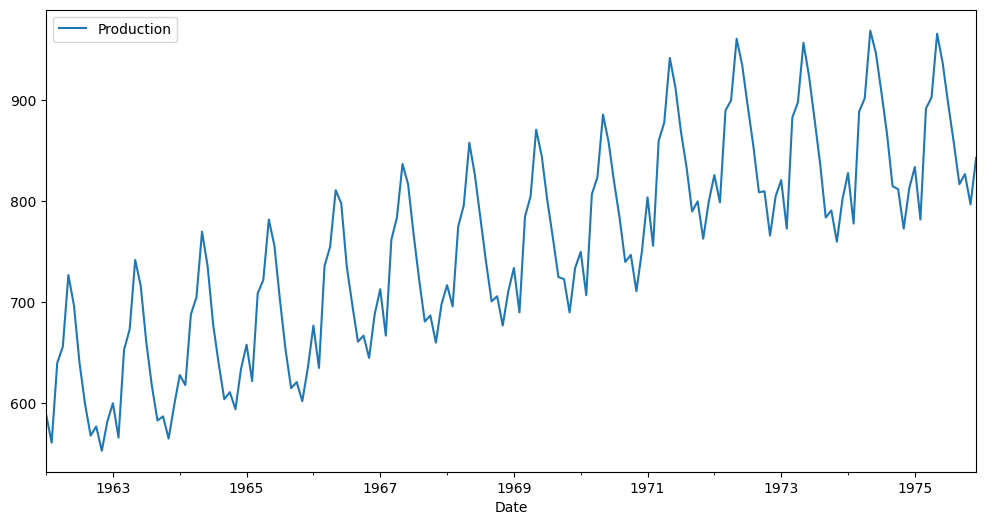

In [ ]:
rnn.plot(figsize=(12,6))

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

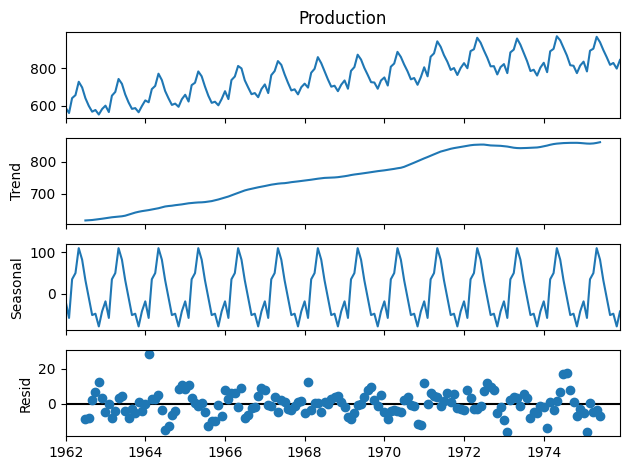

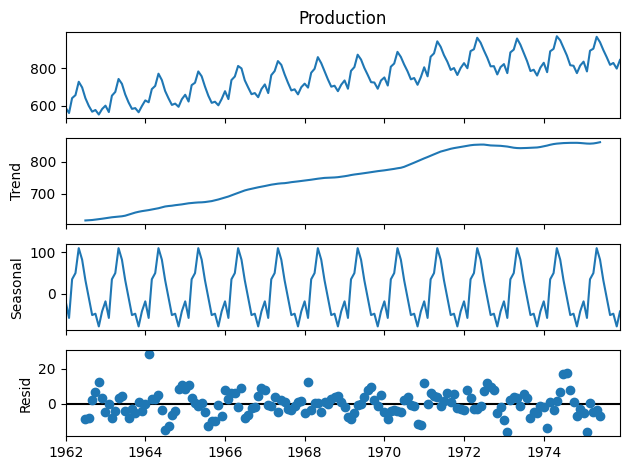

In [ ]:
results = seasonal_decompose(rnn['Production'])
results.plot()

In [ ]:
len(rnn)

168

In [ ]:
train = rnn.iloc[:156]
test = rnn.iloc[156:]

In [ ]:
rnn.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 1962-01-01 to 1975-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Production  168 non-null    int64
dtypes: int64(1)
memory usage: 2.6 KB


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [ ]:
rnn.head(), rnn.tail()

(            Production
 Date                  
 1962-01-01         589
 1962-02-01         561
 1962-03-01         640
 1962-04-01         656
 1962-05-01         727,
             Production
 Date                  
 1975-08-01         858
 1975-09-01         817
 1975-10-01         827
 1975-11-01         797
 1975-12-01         843)

In [ ]:
scaled_train = scaler.fit_transform(train)
scaled_test = scaler.transform(test)

In [ ]:
scaled_train[:10]

array([[0.08653846],
       [0.01923077],
       [0.20913462],
       [0.24759615],
       [0.41826923],
       [0.34615385],
       [0.20913462],
       [0.11057692],
       [0.03605769],
       [0.05769231]])

In [ ]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

In [ ]:
n_input = 3
n_feature = 1
gen = TimeseriesGenerator(scaled_train, scaled_train, length=n_input, batch_size=1)

In [ ]:
x, y = gen[0]
print(f'Given the Array : \n{x.flatten()}')
print(f'Predict this y : \n{y}')

Given the Array : 
[0.08653846 0.01923077 0.20913462]
Predict this y : 
[[0.24759615]]


In [ ]:
n_input = 12
gen = TimeseriesGenerator(scaled_train, scaled_train, length=n_input, batch_size=1)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [ ]:
model = Sequential()
model.add(LSTM(100, activation='relu', input_shape=(n_input,1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.fit(gen, epochs=100)

Epoch 1/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0374
Epoch 2/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0225
Epoch 3/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0174
Epoch 4/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0092
Epoch 5/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0095
Epoch 6/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0054
Epoch 7/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0056
Epoch 8/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0057
Epoch 9/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0051
Epoch 10/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0041
Epoch 11/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0049
Epoch 12/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0035
Epoch 13/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0034
Epoch 14/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0037
Epoch 15/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1

In [ ]:
last_train_batch = scaled_train[-12:]

In [ ]:
last_train_batch = last_train_batch.reshape((1, n_input,1))

In [ ]:
model.predict(last_train_batch)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step


array([[0.65796316]], dtype=float32)

In [ ]:
scaled_test[0]

array([0.67548077])

In [ ]:
test_predictions = []#157

first_eval_batch = scaled_train[-n_input:]
current_batch = first_eval_batch.reshape((1, n_input, n_feature)) #157

for i in range(len(test)):

    # get the prediction value for the first batch
    current_pred = model.predict(current_batch)[0]
    print(current_pred)
    # append the prediction into the array
    test_predictions.append(current_pred)

    # use the prediction to update the batch and remove the first value
    current_batch = np.append(current_batch[:,1:],[[current_pred]],axis=1)
    print(current_batch)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
[0.65796316]
[[[0.54086538]
  [0.80769231]
  [0.83894231]
  [1.        ]
  [0.94711538]
  [0.85336538]
  [0.75480769]
  [0.62980769]
  [0.62259615]
  [0.52884615]
  [0.625     ]
  [0.65796316]]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
[0.5983034]
[[[0.80769231]
  [0.83894231]
  [1.        ]
  [0.94711538]
  [0.85336538]
  [0.75480769]
  [0.62980769]
  [0.62259615]
  [0.52884615]
  [0.625     ]
  [0.65796316]
  [0.59830338]]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
[0.79846567]
[[[0.83894231]
  [1.        ]
  [0.94711538]
  [0.85336538]
  [0.75480769]
  [0.62980769]
  [0.62259615]
  [0.52884615]
  [0.625     ]
  [0.65796316]
  [0.59830338]
  [0.79846567]]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
[0.84315133]
[[[1.        ]
  [0.94711538]
  [0.85336538]
  [0.75480769]
  [0.62980769]
  [0.62259615]
  [0.52884615]
  [0.625     ]
  [0.65796316]
  [0.59830338]
  [0.79846567]
  [0.84315133]]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
[0.9795738]
[[[0.94711538]
  [0

In [ ]:
test_predictions

[array([0.65796316], dtype=float32),
 array([0.5983034], dtype=float32),
 array([0.79846567], dtype=float32),
 array([0.84315133], dtype=float32),
 array([0.9795738], dtype=float32),
 array([0.95141685], dtype=float32),
 array([0.8816085], dtype=float32),
 array([0.7755678], dtype=float32),
 array([0.66356015], dtype=float32),
 array([0.62931174], dtype=float32),
 array([0.562916], dtype=float32),
 array([0.618156], dtype=float32)]

In [ ]:
true_predictions = scaler.inverse_transform(test_predictions)
test['Predictions'] = true_predictions

/tmp/ipykernel_3406/4268826688.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Predictions'] = true_predictions


In [ ]:
test.head()

,Production,Predictions
Date,,
1975-01-01,834,826.712673
1975-02-01,782,801.894205
1975-03-01,892,885.161718
1975-04-01,903,903.750954
1975-05-01,966,960.502695


In [ ]:
from sklearn.metrics import r2_score
rnn_score = r2_score(test['Production'], test['Predictions'])
rnn_score

0.9145108319354727